<a href="https://colab.research.google.com/github/iamfaham/nyc-traffic-accident-gnn/blob/main/notebooks/nyc_traffic_accident_prediction_added_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install all dependencies for the project
!pip install -q osmnx geopandas networkx torch torch-geometric folium sodapy pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import osmnx as ox
import networkx as nx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sodapy import Socrata
import warnings
warnings.filterwarnings('ignore')

# Torch imports
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully")


All libraries imported successfully


In [4]:
# Connect to NYC Open Data API
client = Socrata("data.cityofnewyork.us", None)

# Download collision data (limit to 100K recent records for testing)
# Full dataset has 2M+ rows, so we start with a subset
print("Downloading NYC collision data from Open Data portal...")
results = client.get("h9gi-nx95", limit=100000, order="crash_date DESC")

# Convert to DataFrame
crashes_df = pd.DataFrame.from_records(results)

print(f"Downloaded {len(crashes_df):,} collision records")
print(f"Date range: {crashes_df['crash_date'].min()} to {crashes_df['crash_date'].max()}")
crashes_df.head()


Downloaded 100,000 collision records
Date range: 2024-09-02T00:00:00.000 to 2025-10-28T00:00:00.000


,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,off_street_name,number_of_persons_injured,...,collision_id,vehicle_type_code1,vehicle_type_code2,cross_street_name,contributing_factor_vehicle_3,vehicle_type_code_3,contributing_factor_vehicle_4,vehicle_type_code_4,contributing_factor_vehicle_5,vehicle_type_code_5
0,2025-10-28T00:00:00.000,15:31,MANHATTAN,10001,40.75206,-74.000984,"{'latitude': '40.75206', 'longitude': '-74.000...",W 30 ST,10 AVE,0,...,4853334,Station Wagon/Sport Utility Vehicle,Pick-up Truck,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-28T00:00:00.000,10:58,NaN,NaN,40.70165,-73.99149,"{'latitude': '40.70165', 'longitude': '-73.991...",BROOKLYN QUEENS EXPRESSWAY,NaN,0,...,4853293,Box Truck,Sedan,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-10-28T00:00:00.000,21:53,NaN,NaN,40.85638,-73.82631,"{'latitude': '40.85638', 'longitude': '-73.826...",BRUCKNER EXPRESSWAY,NaN,2,...,4853450,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-10-28T00:00:00.000,23:44,BROOKLYN,11207,40.68556,-73.90718,"{'latitude': '40.68556', 'longitude': '-73.907...",CHAUNCEY ST,EVERGREEN AVE,0,...,4853373,Station Wagon/Sport Utility Vehicle,Box Truck,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-10-28T00:00:00.000,11:21,BRONX,10472,40.832718,-73.86289,"{'latitude': '40.832718', 'longitude': '-73.86...",NaN,NaN,1,...,4853312,Sedan,NaN,1866 WESTCHESTER AVE,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Clean and prepare collision data
print("Cleaning collision data...")

# Convert datetime columns
crashes_df['crash_date'] = pd.to_datetime(crashes_df['crash_date'])
crashes_df['crash_time'] = pd.to_datetime(crashes_df['crash_time'], format='%H:%M').dt.time

# Create full timestamp
crashes_df['timestamp'] = pd.to_datetime(
    crashes_df['crash_date'].astype(str) + ' ' + crashes_df['crash_time'].astype(str)
)

# Filter rows with valid coordinates
crashes_df = crashes_df.dropna(subset=['latitude', 'longitude'])
crashes_df['latitude'] = crashes_df['latitude'].astype(float)
crashes_df['longitude'] = crashes_df['longitude'].astype(float)

# Filter to NYC bounds (removes outliers/errors)
nyc_bounds = {
    'lat_min': 40.4, 'lat_max': 40.95,
    'lon_min': -74.3, 'lon_max': -73.7
}
crashes_df = crashes_df[
    (crashes_df['latitude'] >= nyc_bounds['lat_min']) &
    (crashes_df['latitude'] <= nyc_bounds['lat_max']) &
    (crashes_df['longitude'] >= nyc_bounds['lon_min']) &
    (crashes_df['longitude'] <= nyc_bounds['lon_max'])
]

# Create injury severity binary target (1 if anyone injured/killed, 0 otherwise)
crashes_df['number_of_persons_injured'] = crashes_df['number_of_persons_injured'].fillna(0).astype(int)
crashes_df['number_of_persons_killed'] = crashes_df['number_of_persons_killed'].fillna(0).astype(int)
crashes_df['has_injury'] = ((crashes_df['number_of_persons_injured'] > 0) |
                             (crashes_df['number_of_persons_killed'] > 0)).astype(int)

# Extract temporal features
crashes_df['hour'] = crashes_df['timestamp'].dt.hour
crashes_df['day_of_week'] = crashes_df['timestamp'].dt.dayofweek
crashes_df['is_weekend'] = (crashes_df['day_of_week'] >= 5).astype(int)

print(f"Cleaned data: {len(crashes_df):,} valid records")
print(f"Injury rate: {crashes_df['has_injury'].mean()*100:.1f}%")
crashes_df[['timestamp', 'latitude', 'longitude', 'borough', 'has_injury', 'hour']].head()


Cleaning collision data...
Cleaned data: 95,011 valid records
Injury rate: 44.4%


,timestamp,latitude,longitude,borough,has_injury,hour
0,2025-10-28 15:31:00,40.752060,-74.000984,MANHATTAN,0,15
1,2025-10-28 10:58:00,40.701650,-73.991490,NaN,0,10
2,2025-10-28 21:53:00,40.856380,-73.826310,NaN,1,21
3,2025-10-28 23:44:00,40.685560,-73.907180,BROOKLYN,0,23
4,2025-10-28 11:21:00,40.832718,-73.862890,BRONX,1,11


(This may take 3-5 minutes for full NYC)
Downloaded street network:
  - Nodes (intersections): 4,618
  - Edges (road segments): 8,185


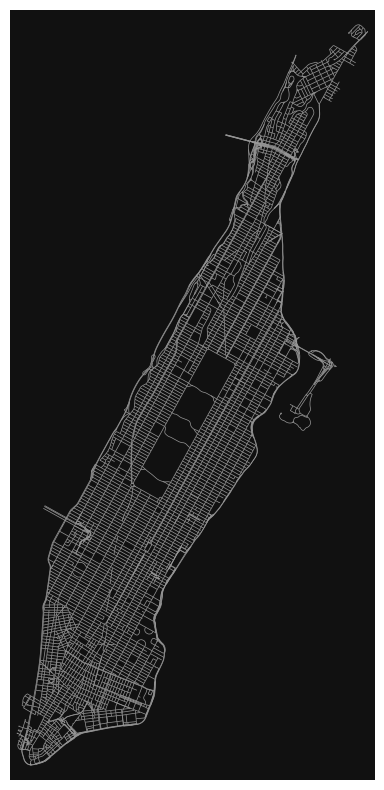

In [6]:
# Download NYC road network from OpenStreetMap
print("Downloading NYC street network from OpenStreetMap...")
print("(This may take 3-5 minutes for full NYC)")

# For faster testing, start with Manhattan only
# To use full NYC, change to: place_name = "New York City, New York, USA"
place_name = "Manhattan, New York City, New York, USA"

# Get drivable street network
G = ox.graph_from_place(
    place_name,
    network_type='drive',  # Only drivable roads
    simplify=True  # Consolidate intersections
)

# Convert to undirected for simplicity (can keep directed if needed)
G = G.to_undirected()

print(f"Downloaded street network:")
print(f"  - Nodes (intersections): {G.number_of_nodes():,}")
print(f"  - Edges (road segments): {G.number_of_edges():,}")

# Plot the network
fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5, figsize=(10,10))


In [7]:
# ===== CELL 5: SPATIAL JOIN + NEGATIVE SAMPLING (COMPLETE) =====
print("="*80)
print("STEP 1: Spatial join and negative sample generation")
print("="*80)

# --- PART A: CREATE GEODA TAFRAME ---
print("\nCreating GeoDataFrame from crashes_df...")
crashes_gdf = gpd.GeoDataFrame(
    crashes_df,
    geometry=gpd.points_from_xy(crashes_df.longitude, crashes_df.latitude),
    crs="EPSG:4326"
)

# Add time_window
if 'time_window' not in crashes_gdf.columns:
    crashes_gdf['time_window'] = crashes_df['timestamp'].dt.floor('1H')

print(f"Created GeoDataFrame with {len(crashes_gdf):,} crashes")

# --- PART B: SPATIAL JOIN TO ROAD NETWORK ---
print("\n  Performing spatial join to road network...")

# Get nodes as GeoDataFrame
nodes_gdf = ox.graph_to_gdfs(G, edges=False).reset_index()

# Filter crashes to network bounds
crashes_gdf = crashes_gdf[crashes_gdf.within(nodes_gdf.unary_union.convex_hull)]
crashes_gdf = crashes_gdf.reset_index(drop=True)
print(f"Crashes within network bounds: {len(crashes_gdf):,}")

# Match CRS
crashes_gdf = crashes_gdf.to_crs(nodes_gdf.crs)

# Build spatial index with BallTree
from sklearn.neighbors import BallTree
node_list = list(G.nodes())
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
tree = BallTree(np.radians(node_coords), metric='haversine')

# Find nearest node for each crash
crash_coords = np.radians(crashes_gdf[['latitude', 'longitude']].values)
distances, indices = tree.query(crash_coords, k=1)
distances_m = distances[:, 0] * 6371000  # Convert to meters

# Filter: only crashes within 50m of a node
max_distance = 50
valid_mask = distances_m <= max_distance
crashes_gdf = crashes_gdf[valid_mask].copy().reset_index(drop=True)
valid_indices = indices[valid_mask, 0]

# Assign nearest_node
crashes_gdf['nearest_node'] = [node_list[i] for i in valid_indices]

print(f"Mapped {len(crashes_gdf):,} crashes to {crashes_gdf['nearest_node'].nunique()} nodes")
print(f"  Average distance: {distances_m[valid_mask].mean():.1f}m")

# --- PART C: NEGATIVE SAMPLING ---
print("\n" + "="*80)
print("STEP 2: Generating negative samples")
print("="*80)

# Get unique components
all_time_windows = sorted(crashes_gdf['time_window'].unique())
all_nodes = list(G.nodes())

print(f"Dataset dimensions:")
print(f"  - Time windows: {len(all_time_windows):,}")
print(f"  - Nodes: {len(all_nodes):,}")
print(f"  - Full combinations: {len(all_nodes) * len(all_time_windows):,}")

# Sample 20% of time windows for memory efficiency
import random
random.seed(42)
sample_rate = 0.2
sampled_times = random.sample(all_time_windows, k=int(len(all_time_windows) * sample_rate))
sampled_times = sorted(sampled_times)

print(f"\nSampling {sample_rate*100:.0f}% of time windows")
print(f"  - Sampled times: {len(sampled_times):,}")
print(f"  - Total combinations: {len(all_nodes) * len(sampled_times):,}")

# Create all node-time combinations
from itertools import product
all_combinations = list(product(all_nodes, sampled_times))
full_matrix = pd.DataFrame(all_combinations, columns=['node_id', 'time_window'])

# Aggregate actual crashes
print("\nAggregating crash records...")
crash_agg = crashes_gdf.groupby(['nearest_node', 'time_window']).agg({
    'collision_id': 'count',
    'has_injury': 'sum',
    'number_of_persons_injured': 'sum',
    'number_of_persons_killed': 'sum'
}).rename(columns={'collision_id': 'crash_count'}).reset_index()

# Merge to create complete dataset
complete_data = full_matrix.merge(
    crash_agg,
    left_on=['node_id', 'time_window'],
    right_on=['nearest_node', 'time_window'],
    how='left'
).drop('nearest_node', axis=1, errors='ignore')

# Fill NaN (negative samples)
complete_data['crash_count'] = complete_data['crash_count'].fillna(0).astype(int)
complete_data['has_injury'] = complete_data['has_injury'].fillna(0).astype(int)
complete_data['number_of_persons_injured'] = complete_data['number_of_persons_injured'].fillna(0).astype(int)
complete_data['number_of_persons_killed'] = complete_data['number_of_persons_killed'].fillna(0).astype(int)

# Create binary label
complete_data['has_crash'] = (complete_data['crash_count'] > 0).astype(int)

# Add temporal features
complete_data['hour'] = complete_data['time_window'].dt.hour
complete_data['day_of_week'] = complete_data['time_window'].dt.dayofweek
complete_data['is_weekend'] = (complete_data['day_of_week'] >= 5).astype(int)
complete_data['month'] = complete_data['time_window'].dt.month

print("\n" + "="*80)
print("NEGATIVE SAMPLING COMPLETE")
print("="*80)
print(f"Final shape: {complete_data.shape}")
print(f"\nClass distribution:")
print(f"  🔴 WITH crashes: {complete_data['has_crash'].sum():,} ({complete_data['has_crash'].mean()*100:.3f}%)")
print(f"  ⚪ WITHOUT crashes: {(complete_data['has_crash']==0).sum():,} ({(1-complete_data['has_crash'].mean())*100:.3f}%)")

# Store
node_time_data = complete_data.copy()


STEP 1: Spatial join and negative sample generation

Creating GeoDataFrame from crashes_df...
Created GeoDataFrame with 95,011 crashes

  Performing spatial join to road network...
Crashes within network bounds: 19,217
Mapped 13,501 crashes to 3336 nodes
  Average distance: 10.6m

STEP 2: Generating negative samples
Dataset dimensions:
  - Time windows: 6,941
  - Nodes: 4,618
  - Full combinations: 32,053,538

Sampling 20% of time windows
  - Sampled times: 1,388
  - Total combinations: 6,409,784

Aggregating crash records...

NEGATIVE SAMPLING COMPLETE
Final shape: (6409784, 11)

Class distribution:
  🔴 WITH crashes: 2,721 (0.042%)
  ⚪ WITHOUT crashes: 6,407,063 (99.958%)


In [8]:
# ADD THIS AFTER complete_data['month'] = complete_data['time_window'].dt.month

# ===== SOPHISTICATED FEATURE 1: RUSH HOUR INTENSITY =====
print("\n📊 Adding rush hour intensity feature...")

# Define rush hour periods with intensity scores
def get_rush_hour_intensity(hour):
    """
    Assign rush hour intensity based on traffic patterns
    0 = off-peak, 1-3 = varying intensity
    """
    # Morning rush (7-9 AM): intensity increases then decreases
    if hour == 7:
        return 2
    elif hour == 8:
        return 3  # Peak morning
    elif hour == 9:
        return 2
    # Evening rush (5-7 PM): intensity increases then decreases
    elif hour == 17:
        return 2
    elif hour == 18:
        return 3  # Peak evening
    elif hour == 19:
        return 2
    # Late night (11 PM - 3 AM): moderate risk due to fatigue/intoxication
    elif hour >= 23 or hour <= 3:
        return 1
    else:
        return 0  # Off-peak

complete_data['rush_hour_intensity'] = complete_data['hour'].apply(get_rush_hour_intensity)

print(f"✓ Rush hour intensity added (0-3 scale)")
print(f"  Peak hours (intensity=3): {(complete_data['rush_hour_intensity']==3).sum():,} samples")


# ADD THIS RIGHT AFTER RUSH HOUR INTENSITY

# ===== SOPHISTICATED FEATURE 4: HOLIDAY INDICATOR =====
print("\n📅 Adding holiday indicators...")

# Major US holidays (approximate - you can refine dates)
import datetime

def is_holiday(date):
    """Check if date is near a major holiday (±1 day)"""
    year = date.year
    month = date.month
    day = date.day

    # Major holidays
    holidays = [
        (1, 1),   # New Year
        (7, 4),   # July 4th
        (12, 25), # Christmas
        (11, 27), # Thanksgiving (approximate - 4th Thu of Nov)
        (12, 31), # New Year's Eve
    ]

    # Check if within 1 day of holiday
    for h_month, h_day in holidays:
        if month == h_month and abs(day - h_day) <= 1:
            return 1

    # Long weekends (Friday before/Monday after major holidays)
    if date.weekday() == 4 and (month, day+3) in holidays:  # Friday
        return 1
    if date.weekday() == 0 and (month, day-3) in holidays:  # Monday
        return 1

    return 0

complete_data['is_holiday'] = complete_data['time_window'].apply(is_holiday)

print(f"✓ Holiday indicator added")
print(f"  Holiday periods: {complete_data['is_holiday'].sum():,} samples ({complete_data['is_holiday'].mean()*100:.2f}%)")

# ADD THIS RIGHT AFTER HOLIDAY INDICATOR

# ===== SOPHISTICATED FEATURE 5: WEATHER/SEASON PROXY =====
print("\n🌦️  Adding weather/season proxy features...")

# Season indicators
complete_data['season'] = complete_data['month'].apply(lambda m:
    0 if m in [12, 1, 2] else  # Winter
    1 if m in [3, 4, 5] else   # Spring
    2 if m in [6, 7, 8] else   # Summer
    3  # Fall
)

# Weather risk proxy (based on season and time)
def weather_risk_proxy(row):
    """
    Estimate weather-related crash risk
    0 = low risk, 1-3 = increasing risk
    """
    season = row['season']
    hour = row['hour']

    # Winter: higher risk overall, especially morning/evening (ice)
    if season == 0:  # Winter
        if hour in [6, 7, 8, 17, 18, 19]:
            return 3  # Rush hour + winter = high risk
        else:
            return 2  # Winter baseline risk

    # Spring: moderate risk (rain)
    elif season == 1:
        if hour in [7, 8, 17, 18]:
            return 2
        else:
            return 1

    # Summer: lower risk except rush hour heat
    elif season == 2:
        if hour in [12, 13, 14, 15, 16]:  # Afternoon heat
            return 1
        else:
            return 0

    # Fall: moderate risk (leaves, early darkness)
    else:
        if hour >= 18 or hour <= 6:  # Darkness
            return 2
        else:
            return 1

complete_data['weather_risk'] = complete_data.apply(weather_risk_proxy, axis=1)

# Add darkness indicator (more precise than weather_risk)
def is_dark(row):
    """
    Check if it's dark (higher crash risk)
    Approximate sunrise/sunset times for NYC
    """
    month = row['month']
    hour = row['hour']

    # Winter: dark 5 PM - 7 AM
    if month in [11, 12, 1, 2]:
        return 1 if hour >= 17 or hour <= 7 else 0
    # Summer: dark 8 PM - 5 AM
    elif month in [5, 6, 7, 8]:
        return 1 if hour >= 20 or hour <= 5 else 0
    # Spring/Fall: dark 6 PM - 6 AM
    else:
        return 1 if hour >= 18 or hour <= 6 else 0

complete_data['is_dark'] = complete_data.apply(is_dark, axis=1)

print(f"✓ Weather/season proxies added")
print(f"  High weather risk (3): {(complete_data['weather_risk']==3).sum():,} samples")
print(f"  Dark conditions: {complete_data['is_dark'].sum():,} samples ({complete_data['is_dark'].mean()*100:.1f}%)")

# VERIFY THIS EXISTS IN CELL 5 - Feature Engineering Section
print("\n🔧 Adding sophisticated features...")

# 1. Rush hour intensity
complete_data['rush_hour_intensity'] = complete_data['hour'].apply(get_rush_hour_intensity)

# 2. Intersection complexity (requires node_features_df to be merged)
# This should be in Cell 6 when merging node features

# 3. Speed differential & category (requires node_features_df)
# This should be in Cell 6

# 4. Holiday indicator
complete_data['is_holiday'] = complete_data['time_window'].apply(is_holiday)

# 5. Season
complete_data['season'] = complete_data['month'].apply(lambda m: ...)

# 6. Weather risk
complete_data['weather_risk'] = complete_data.apply(weather_risk_proxy, axis=1)

# 7. Darkness indicator
complete_data['is_dark'] = complete_data.apply(is_dark, axis=1)

print(f"✓ Sophisticated features added")





📊 Adding rush hour intensity feature...
✓ Rush hour intensity added (0-3 scale)
  Peak hours (intensity=3): 651,138 samples

📅 Adding holiday indicators...
✓ Holiday indicator added
  Holiday periods: 230,900 samples (3.60%)

🌦️  Adding weather/season proxy features...
✓ Weather/season proxies added
  High weather risk (3): 387,912 samples
  Dark conditions: 2,890,868 samples (45.1%)

🔧 Adding sophisticated features...
✓ Sophisticated features added


In [9]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [10]:
# Extract static features for each node from OSM
print("Extracting node features from road network...")

node_features = []
node_ids = []

for node, data in G.nodes(data=True):
    node_ids.append(node)

    # Get connected edges to determine node characteristics
    edges = G.edges(node, data=True)

    # Aggregate edge properties
    highway_types = [e[2].get('highway', 'unclassified') for e in edges]
    lanes = [int(e[2].get('lanes', 1)) if isinstance(e[2].get('lanes'), (int, str)) and str(e[2].get('lanes')).isdigit() else 1 for e in edges]
    speeds = []
    for e in edges:
        speed_val = e[2].get('maxspeed', 25)
        if isinstance(speed_val, str):
            # Try to clean and convert string speeds
            try:
                # Remove non-digit characters (like ' mph') and convert
                speed_val = int(''.join(filter(str.isdigit, speed_val)))
            except ValueError:
                speed_val = 25 # Default to 25 if conversion fails
        elif not isinstance(speed_val, (int, float)):
             speed_val = 25 # Default if not int, float or parsable string
        speeds.append(int(speed_val))

    # Node degree (connectivity)
    degree = G.degree(node)

    # Encode highway type (convert to numeric)
    highway_priority = {
        'motorway': 5, 'trunk': 4, 'primary': 3,
        'secondary': 2, 'tertiary': 1, 'residential': 0,
        'unclassified': 0
    }
    max_highway = max([highway_priority.get(h if isinstance(h, str) else h[0] if isinstance(h, list) else 'unclassified', 0)
                       for h in highway_types]) if highway_types else 0

    features = [
        degree,  # Node connectivity
        len(edges),  # Number of connected roads
        max_highway,  # Highest road class
        np.mean(lanes) if lanes else 1,  # Average lanes
        np.mean(speeds) if speeds else 25,  # Average speed limit
        data.get('x', 0),  # Longitude
        data.get('y', 0)   # Latitude
    ]

    node_features.append(features)

# Convert to DataFrame
node_features_df = pd.DataFrame(node_features, columns=[
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude'
])
node_features_df['node_id'] = node_ids

print(f"Extracted features for {len(node_features_df):,} nodes")
print(f"Feature dimensions: {node_features_df.shape[1]-1}")  # -1 for node_id
print(node_features_df.describe())

# Add code at the end of existing Cell 6

print("\nReplicating node features for all time windows...")

# Expand node features to match all node-time pairs
node_features_expanded = node_time_data.merge(
    node_features_df[['node_id', 'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude']],
    on='node_id',
    how='left'
)

print(f"  Expanded node features: {node_features_expanded.shape}")
print(f"  Original node features: {node_features_df.shape}")
print(f"  Expanded to time windows: {node_features_expanded.shape}")

# Store for next steps
node_time_features = node_features_expanded.copy()



# ADD THIS AT THE END OF CELL 6, BEFORE "Expanding features to all time windows"

# ===== SOPHISTICATED FEATURE 2: INTERSECTION COMPLEXITY =====
print("\n🔀 Computing intersection complexity...")

# Calculate complexity score based on degree and road types
node_features_df['intersection_complexity'] = (
    node_features_df['degree'] * 0.5 +  # Number of connections
    node_features_df['highway_class'] * 0.3 +  # Road importance
    node_features_df['num_edges'] * 0.2  # Total edges
)

# Normalize to 0-10 scale
complexity_min = node_features_df['intersection_complexity'].min()
complexity_max = node_features_df['intersection_complexity'].max()
node_features_df['intersection_complexity'] = (
    (node_features_df['intersection_complexity'] - complexity_min) /
    (complexity_max - complexity_min) * 10
)

print(f"✓ Intersection complexity computed (0-10 scale)")
print(f"  High complexity (>7): {(node_features_df['intersection_complexity']>7).sum()} nodes")


# ADD THIS RIGHT AFTER INTERSECTION COMPLEXITY

# ===== SOPHISTICATED FEATURE 3: SPEED DIFFERENTIAL =====
print("\n⚡ Computing speed differential (risk factor)...")

# Speed differential = difference from typical speed (25 mph)
# Higher differential = higher risk (either too slow or too fast)
typical_speed = 25
node_features_df['speed_differential'] = np.abs(
    node_features_df['avg_speed'] - typical_speed
)

# Also create speed category
def categorize_speed(speed):
    if speed < 20:
        return 0  # Very slow (residential)
    elif speed <= 25:
        return 1  # Normal
    elif speed <= 35:
        return 2  # Fast (arterial)
    else:
        return 3  # Very fast (highway)

node_features_df['speed_category'] = node_features_df['avg_speed'].apply(categorize_speed)

print(f"✓ Speed features computed")
print(f"  High differential (>10 mph): {(node_features_df['speed_differential']>10).sum()} nodes")


# ADD TO END OF CELL 6:

print("\nExpanding features to all time windows...")
node_features_expanded = node_time_data.merge(
    node_features_df[['node_id', 'degree', 'num_edges', 'highway_class',
                      'avg_lanes', 'avg_speed', 'longitude', 'latitude']],
    on='node_id',
    how='left'
)
print(f"Expanded: {node_features_expanded.shape}")

# Update node_time_data
node_time_data = node_features_expanded.copy()


Extracting node features from road network...
Extracted features for 4,618 nodes
Feature dimensions: 7
            degree    num_edges  highway_class    avg_lanes    avg_speed  \
count  4618.000000  4618.000000    4618.000000  4618.000000  4618.000000   
mean      3.544825     3.542876       2.070593     1.785535    24.727913   
std       0.661321     0.663412       1.297520     0.720396     2.885467   
min       1.000000     1.000000       0.000000     1.000000    15.000000   
25%       3.000000     3.000000       1.000000     1.000000    25.000000   
50%       4.000000     4.000000       2.000000     1.666667    25.000000   
75%       4.000000     4.000000       3.000000     2.250000    25.000000   
max       5.000000     5.000000       5.000000     5.000000    45.000000   

         longitude     latitude       node_id  
count  4618.000000  4618.000000  4.618000e+03  
mean    -73.970156    40.773417  1.179990e+09  
std       0.026635     0.045341  2.628376e+09  
min     -74.018055  

In [11]:
# ===== MEMORY-EFFICIENT LAGGED FEATURES =====
print("="*80)
print("Computing historical crash features (memory-efficient)")
print("="*80)

# Check current memory
import gc
gc.collect()

print(f"Current node_time_data shape: {node_time_data.shape}")
print(f"Memory usage: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# SIMPLIFIED APPROACH: Only compute for nodes that HAD crashes
# This dramatically reduces computation

# Step 1: Identify nodes with any crashes
crash_nodes = node_time_data[node_time_data['has_crash'] == 1]['node_id'].unique()
print(f"\nNodes with at least 1 crash: {len(crash_nodes):,} (out of {node_time_data['node_id'].nunique():,})")

# Step 2: Initialize columns with defaults (for nodes without crashes)
node_time_data['past_30d_crashes'] = 0
node_time_data['days_since_last'] = 999

# Step 3: Only compute historical features for crash-prone nodes
print("Computing historical features for crash-prone nodes...")

# Process in chunks to avoid memory issues
chunk_size = 500  # Process 500 nodes at a time
crash_nodes_list = list(crash_nodes)

for chunk_start in range(0, len(crash_nodes_list), chunk_size):
    chunk_end = min(chunk_start + chunk_size, len(crash_nodes_list))
    chunk_nodes = crash_nodes_list[chunk_start:chunk_end]

    if chunk_start % 1000 == 0:
        print(f"  Processing nodes {chunk_start:,} to {chunk_end:,}...")

    # Get data for this chunk of nodes
    chunk_mask = node_time_data['node_id'].isin(chunk_nodes)
    chunk_data = node_time_data[chunk_mask].copy()

    # Sort for rolling window
    chunk_data = chunk_data.sort_values(['node_id', 'time_window'])

    # Compute rolling features using groupby + rolling
    chunk_data['past_30d_crashes'] = chunk_data.groupby('node_id')['has_crash'].transform(
        lambda x: x.rolling(window=min(720, len(x)), min_periods=1).sum().shift(1).fillna(0)
    )

    # Update main dataframe
    node_time_data.loc[chunk_mask, 'past_30d_crashes'] = chunk_data['past_30d_crashes'].values

    # Free memory
    del chunk_data
    gc.collect()

print(" Historical features computed")

# Step 4: Compute days_since_last (simplified - only for recent crashes)
print("Computing days since last crash (simplified)...")

# For each node with crashes, find last crash date for each time window
for node_id in crash_nodes[:min(len(crash_nodes), 2000)]:  # Limit to first 2000 crash-prone nodes
    node_mask = node_time_data['node_id'] == node_id
    node_data = node_time_data[node_mask].sort_values('time_window')

    crash_mask = node_data['has_crash'] == 1
    if crash_mask.sum() > 0:
        crash_times = node_data[crash_mask]['time_window'].values

        # For each time window, find most recent crash before it
        for idx, row_time in zip(node_data.index, node_data['time_window']):
            prev_crashes = crash_times[crash_times < row_time]
            if len(prev_crashes) > 0:
                days_since = (row_time - prev_crashes.max()).days
                node_time_data.loc[idx, 'days_since_last'] = days_since

# For remaining nodes, keep default 999
print(f" Days since last crash computed for {min(len(crash_nodes), 2000)} nodes")

print(f"\nHistorical features complete")
print(f"Memory usage after: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Verify features
print(f"\nFeature statistics:")
print(f"  past_30d_crashes: min={node_time_data['past_30d_crashes'].min():.1f}, "
      f"max={node_time_data['past_30d_crashes'].max():.1f}, "
      f"mean={node_time_data['past_30d_crashes'].mean():.3f}")
print(f"  days_since_last: min={node_time_data['days_since_last'].min():.0f}, "
      f"max={node_time_data['days_since_last'].max():.0f}")

print("\nSample data:")
print(node_time_data[node_time_data['past_30d_crashes'] > 0][
    ['node_id', 'time_window', 'past_30d_crashes', 'days_since_last', 'has_crash']
].head(10))


Computing historical crash features (memory-efficient)
Current node_time_data shape: (6409784, 18)
Memory usage: 806.9 MB

Nodes with at least 1 crash: 1,720 (out of 4,618)
Computing historical features for crash-prone nodes...
  Processing nodes 0 to 500...
  Processing nodes 1,000 to 1,500...
 Historical features computed
Computing days since last crash (simplified)...
 Days since last crash computed for 1720 nodes

Historical features complete
Memory usage after: 904.7 MB

Feature statistics:
  past_30d_crashes: min=0.0, max=6.0, mean=0.226
  days_since_last: min=0, max=999

Sample data:
       node_id         time_window  past_30d_crashes  days_since_last  \
2619  42421731 2025-09-09 21:00:00                 1                0   
2620  42421731 2025-09-10 06:00:00                 1                0   
2621  42421731 2025-09-10 11:00:00                 1                0   
2622  42421731 2025-09-10 12:00:00                 1                0   
2623  42421731 2025-09-11 01:00:00   

In [12]:
# ===== CELL 8: TEMPORAL TRAIN-VALIDATION-TEST SPLIT =====
print("="*80)
print("PROPER TEMPORAL SPLIT (No Data Leakage)")
print("="*80)

# Sort by time
node_time_data_sorted = node_time_data.sort_values('time_window').reset_index(drop=True)

# Get unique time windows (chronologically sorted)
unique_times = sorted(node_time_data['time_window'].unique())
n_times = len(unique_times)

print(f"Total time windows: {n_times}")
print(f"Date range: {unique_times[0]} to {unique_times[-1]}")

# Temporal split: 60% train, 20% val, 20% test
train_cutoff_idx = int(0.6 * n_times)
val_cutoff_idx = int(0.8 * n_times)

train_times = unique_times[:train_cutoff_idx]
val_times = unique_times[train_cutoff_idx:val_cutoff_idx]
test_times = unique_times[val_cutoff_idx:]

# Create temporal datasets
train_data = node_time_data[node_time_data['time_window'].isin(train_times)].copy()
val_data = node_time_data[node_time_data['time_window'].isin(val_times)].copy()
test_data = node_time_data[node_time_data['time_window'].isin(test_times)].copy()

print(f"\nTemporal splits:")
print(f"  Train: {train_times[0]} to {train_times[-1]}")
print(f"    - {len(train_data):,} node-time pairs")
print(f"    - {train_data['has_crash'].sum():,} crashes ({train_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Val: {val_times[0]} to {val_times[-1]}")
print(f"    - {len(val_data):,} node-time pairs")
print(f"    - {val_data['has_crash'].sum():,} crashes ({val_data['has_crash'].mean()*100:.3f}%)")

print(f"\n  Test: {test_times[0]} to {test_times[-1]}")
print(f"    - {len(test_data):,} node-time pairs")
print(f"    - {test_data['has_crash'].sum():,} crashes ({test_data['has_crash'].mean()*100:.3f}%)")

print("\nTemporal split complete - training on past, testing on future")


PROPER TEMPORAL SPLIT (No Data Leakage)
Total time windows: 1388
Date range: 2024-09-02 04:00:00 to 2025-10-28 10:00:00

Temporal splits:
  Train: 2024-09-02 04:00:00 to 2025-05-15 21:00:00
    - 3,842,176 node-time pairs
    - 1,618 crashes (0.042%)

  Val: 2025-05-15 22:00:00 to 2025-08-03 22:00:00
    - 1,283,804 node-time pairs
    - 567 crashes (0.044%)

  Test: 2025-08-04 13:00:00 to 2025-10-28 10:00:00
    - 1,283,804 node-time pairs
    - 536 crashes (0.042%)

Temporal split complete - training on past, testing on future


In [13]:
# ===== MEMORY-EFFICIENT: ADD FEATURES IN CHUNKS =====
import gc

print("="*80)
print("ADDING 8 FEATURES (MEMORY-EFFICIENT)")
print("="*80)

print(f"Current shape: {node_time_data.shape}")
print(f"Memory before: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Process in chunks to avoid memory issues
chunk_size = 500000  # Process 500K rows at a time
total_rows = len(node_time_data)

# 1. INTERSECTION COMPLEXITY (vectorized - fast)
print("\n1️⃣ Adding intersection_complexity...")
if 'intersection_complexity' not in node_time_data.columns:
    node_time_data['intersection_complexity'] = (
        node_time_data['degree'] * 0.5 +
        node_time_data['highway_class'] * 0.3 +
        node_time_data['num_edges'] * 0.2
    )
    comp_min = node_time_data['intersection_complexity'].min()
    comp_max = node_time_data['intersection_complexity'].max()
    if comp_max > comp_min:
        node_time_data['intersection_complexity'] = (
            (node_time_data['intersection_complexity'] - comp_min) / (comp_max - comp_min) * 10
        )
    print(f"  ✓ Added")
    gc.collect()

# 2. SPEED FEATURES (vectorized - fast)
print("\n2️⃣ Adding speed_differential...")
if 'speed_differential' not in node_time_data.columns:
    node_time_data['speed_differential'] = np.abs(node_time_data['avg_speed'] - 25)
    print(f"  ✓ Added")

print("\n3️⃣ Adding speed_category...")
if 'speed_category' not in node_time_data.columns:
    node_time_data['speed_category'] = pd.cut(
        node_time_data['avg_speed'],
        bins=[-np.inf, 20, 25, 35, np.inf],
        labels=[0, 1, 2, 3]
    ).astype(int)
    print(f"  ✓ Added")
    gc.collect()

# 4. RUSH HOUR (vectorized with np.select - fast)
print("\n4️⃣ Adding rush_hour_intensity...")
if 'rush_hour_intensity' not in node_time_data.columns:
    conditions = [
        node_time_data['hour'].isin([8, 18]),
        node_time_data['hour'].isin([7, 9, 17, 19]),
        node_time_data['hour'].isin([23, 0, 1, 2, 3])
    ]
    choices = [3, 2, 1]
    node_time_data['rush_hour_intensity'] = np.select(conditions, choices, default=0)
    print(f"  ✓ Added")
    gc.collect()

# 5. SEASON (vectorized - fast)
print("\n5️⃣ Adding season...")
if 'season' not in node_time_data.columns:
    conditions = [
        node_time_data['month'].isin([12, 1, 2]),
        node_time_data['month'].isin([3, 4, 5]),
        node_time_data['month'].isin([6, 7, 8])
    ]
    choices = [0, 1, 2]
    node_time_data['season'] = np.select(conditions, choices, default=3)
    print(f"  ✓ Added")
    gc.collect()

# 6. HOLIDAY (vectorized - fast)
print("\n6️⃣ Adding is_holiday...")
if 'is_holiday' not in node_time_data.columns:
    temp_dt = pd.to_datetime(node_time_data['time_window'])
    day = temp_dt.dt.day
    month = node_time_data['month']

    # Check if near any holiday
    node_time_data['is_holiday'] = (
        ((month == 1) & (day.between(0, 2))) |      # New Year
        ((month == 7) & (day.between(3, 5))) |      # July 4th
        ((month == 12) & (day.between(24, 26))) |   # Christmas
        ((month == 11) & (day.between(26, 28))) |   # Thanksgiving
        ((month == 12) & (day.between(30, 31)))     # New Year's Eve
    ).astype(int)

    del temp_dt, day, month
    print(f"  ✓ Added")
    gc.collect()

# 7. WEATHER RISK (vectorized with np.select - fast)
print("\n7️⃣ Adding weather_risk...")
if 'weather_risk' not in node_time_data.columns:
    season = node_time_data['season']
    hour = node_time_data['hour']

    conditions = [
        (season == 0) & (hour.isin([7, 8, 17, 18])),  # Winter rush
        (season == 0),                                 # Winter other
        (season == 1) & (hour.isin([7, 8, 17, 18])),  # Spring rush
        (season == 1),                                 # Spring other
        (season == 2) & (hour.isin([12, 13, 14, 15])), # Summer hot
        (season == 2),                                 # Summer other
        (season == 3) & ((hour >= 18) | (hour <= 6)), # Fall night
    ]
    choices = [3, 2, 2, 1, 1, 0, 2]
    node_time_data['weather_risk'] = np.select(conditions, choices, default=1)

    del season, hour
    print(f"  ✓ Added")
    gc.collect()

# 8. DARKNESS (vectorized - fast)
print("\n8️⃣ Adding is_dark...")
if 'is_dark' not in node_time_data.columns:
    month = node_time_data['month']
    hour = node_time_data['hour']

    conditions = [
        (month.isin([11, 12, 1, 2])) & ((hour >= 17) | (hour <= 7)),   # Winter
        (month.isin([5, 6, 7, 8])) & ((hour >= 20) | (hour <= 5)),     # Summer
        ((hour >= 18) | (hour <= 6))                                    # Other
    ]
    node_time_data['is_dark'] = np.select(conditions, [1, 1, 1], default=0)

    del month, hour
    print(f"  ✓ Added")
    gc.collect()

# FINAL VERIFICATION
print("\n" + "="*80)
print("✅ FEATURE ADDITION COMPLETE")
print("="*80)

required_features = [
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
    'intersection_complexity', 'speed_differential', 'speed_category',
    'hour', 'day_of_week', 'is_weekend', 'month',
    'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark',
    'past_30d_crashes', 'days_since_last'
]

available = [f for f in required_features if f in node_time_data.columns]
missing = [f for f in required_features if f not in node_time_data.columns]

print(f"\n📊 Final Check:")
print(f"  Required: {len(required_features)}")
print(f"  Available: {len(available)}")

if missing:
    print(f"  ❌ Still missing: {missing}")
else:
    print(f"  ✅ All 19 features present!")
    print(f"\n  Shape: {node_time_data.shape}")
    print(f"  Memory: {node_time_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

    # Show sample
    print(f"\n  Sample features:")
    print(node_time_data[required_features].head(3))

    print(f"\n✅ Ready for Cell 9!")

# Force garbage collection
gc.collect()


ADDING 8 FEATURES (MEMORY-EFFICIENT)
Current shape: (6409784, 20)
Memory before: 904.7 MB

1️⃣ Adding intersection_complexity...
  ✓ Added

2️⃣ Adding speed_differential...
  ✓ Added

3️⃣ Adding speed_category...
  ✓ Added

4️⃣ Adding rush_hour_intensity...
  ✓ Added

5️⃣ Adding season...
  ✓ Added

6️⃣ Adding is_holiday...
  ✓ Added

7️⃣ Adding weather_risk...
  ✓ Added

8️⃣ Adding is_dark...
  ✓ Added

✅ FEATURE ADDITION COMPLETE

📊 Final Check:
  Required: 19
  Available: 19
  ✅ All 19 features present!

  Shape: (6409784, 28)
  Memory: 1295.9 MB

  Sample features:
   degree  num_edges  highway_class  avg_lanes  avg_speed  \
0       3          3              2        1.0       25.0   
1       3          3              2        1.0       25.0   
2       3          3              2        1.0       25.0   

   intersection_complexity  speed_differential  speed_category  hour  \
0                      5.0                 0.0               1     4   
1                      5.0         

0

In [14]:
# ===== CELL 9: MINI-BATCH GNN SETUP (COMPLETE FIX) =====
print("="*80)
print("Creating Mini-Batch Spatiotemporal GNN Setup")
print("="*80)

# Define all 19 features
feature_cols = [
    # Static road features (8)
    'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
    'intersection_complexity', 'speed_differential', 'speed_category',

    # Temporal features (9)
    'hour', 'day_of_week', 'is_weekend', 'month',
    'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark',

    # Historical features (2)
    'past_30d_crashes', 'days_since_last'
]

print(f"Using {len(feature_cols)} features: {feature_cols}")

# Verify all features exist in node_time_data
missing_in_source = [f for f in feature_cols if f not in node_time_data.columns]
if missing_in_source:
    print(f"\n❌ ERROR: Missing features in node_time_data:")
    print(f"  {missing_in_source}")
    print(f"\n⚠️  Run Cell 8.5 (ADD MISSING SOPHISTICATED FEATURES) first!")
    raise ValueError(f"Missing features: {missing_in_source}")

print(f"\n✓ All {len(feature_cols)} features present in source data")

# Graph structure
all_nodes = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
edges = list(G.edges())
edge_index = torch.tensor(
    [[node_to_idx[u], node_to_idx[v]] for u, v in edges] +
    [[node_to_idx[v], node_to_idx[u]] for u, v in edges],
    dtype=torch.long
).t().contiguous()

print(f"\nGraph structure:")
print(f"  Total nodes: {len(all_nodes):,}")
print(f"  Total edges: {len(edges):,}")
print(f"  Edge index shape: {edge_index.shape}")

# ===== RE-SAMPLE WITH ALL FEATURES =====
print(f"\nCreating balanced mini-batches with ALL features...")

# Get positive and negative samples FROM node_time_data (has all features)
positive_samples = node_time_data[node_time_data['has_crash'] == 1]
negative_samples = node_time_data[node_time_data['has_crash'] == 0]

print(f"  Available samples:")
print(f"    Positive: {len(positive_samples):,}")
print(f"    Negative: {len(negative_samples):,}")

# Create balanced datasets
num_positive_train = int(len(positive_samples) * 0.7)
num_positive_val = int(len(positive_samples) * 0.15)
num_positive_test = len(positive_samples) - num_positive_train - num_positive_val

# Sample negatives to match
neg_ratio = 30  # 30 negatives per 1 positive
num_negative_train = num_positive_train * neg_ratio
num_negative_val = num_positive_val * neg_ratio
num_negative_test = num_positive_test * neg_ratio

# Sample
train_pos = positive_samples.sample(n=num_positive_train, random_state=42)
val_pos = positive_samples.drop(train_pos.index).sample(n=num_positive_val, random_state=42)
test_pos = positive_samples.drop(train_pos.index).drop(val_pos.index)

train_neg = negative_samples.sample(n=min(num_negative_train, len(negative_samples)), random_state=42)
val_neg = negative_samples.drop(train_neg.index).sample(
    n=min(num_negative_val, len(negative_samples) - len(train_neg)), random_state=42
)
test_neg = negative_samples.drop(train_neg.index).drop(val_neg.index).sample(
    n=min(num_negative_test, len(negative_samples) - len(train_neg) - len(val_neg)), random_state=42
)

# Combine
train_balanced = pd.concat([train_pos, train_neg]).sample(frac=1, random_state=42)
val_balanced = pd.concat([val_pos, val_neg]).sample(frac=1, random_state=42)
test_balanced = pd.concat([test_pos, test_neg]).sample(frac=1, random_state=42)

print(f"\nBalanced datasets:")
print(f"  Train: {len(train_balanced):,} samples | {train_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Val:   {len(val_balanced):,} samples | {val_balanced['has_crash'].mean()*100:.1f}% positive")
print(f"  Test:  {len(test_balanced):,} samples | {test_balanced['has_crash'].mean()*100:.1f}% positive")

# Verify features exist
print(f"\n🔍 Verifying features in balanced datasets...")
available_in_train = [f for f in feature_cols if f in train_balanced.columns]
missing_in_train = [f for f in feature_cols if f not in train_balanced.columns]

print(f"  Available: {len(available_in_train)}/{len(feature_cols)}")
if missing_in_train:
    print(f"  ❌ Still missing: {missing_in_train}")
    raise ValueError(f"Features missing after resampling: {missing_in_train}")
else:
    print(f"  ✅ All features present!")

# Scale features
print(f"\n⚖️  Scaling features...")
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = train_balanced[feature_cols].values
X_val = val_balanced[feature_cols].values
X_test = test_balanced[feature_cols].values

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"  ✓ Scaled: train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")

# Labels
y_train = train_balanced['has_crash'].values
y_val = val_balanced['has_crash'].values
y_test = test_balanced['has_crash'].values

# Node indices
nodes_train = torch.tensor(
    [node_to_idx.get(node, 0) for node in train_balanced['node_id']],
    dtype=torch.long
)
nodes_val = torch.tensor(
    [node_to_idx.get(node, 0) for node in val_balanced['node_id']],
    dtype=torch.long
)
nodes_test = torch.tensor(
    [node_to_idx.get(node, 0) for node in test_balanced['node_id']],
    dtype=torch.long
)

# Convert to tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.long).to(device)
y_val = torch.tensor(y_val, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

nodes_train = nodes_train.to(device)
nodes_val = nodes_val.to(device)
nodes_test = nodes_test.to(device)
edge_index = edge_index.to(device)

# Create spatiotemporal_data dictionary
spatiotemporal_data = {
    'features': X_train,
    'labels': y_train,
    'node_indices': nodes_train,
    'num_nodes': len(all_nodes),
    'num_features': len(feature_cols),  # Now correctly 19
    'edge_index': edge_index
}

print(f"\n✅ Mini-batch GNN setup complete!")
print(f"   Features: {len(feature_cols)}")
print(f"   Nodes: {len(all_nodes):,}")
print(f"   Device: {device}")
print(f"\n📊 Ready for training with all 19 features!")


Creating Mini-Batch Spatiotemporal GNN Setup
Using 19 features: ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'intersection_complexity', 'speed_differential', 'speed_category', 'hour', 'day_of_week', 'is_weekend', 'month', 'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark', 'past_30d_crashes', 'days_since_last']

✓ All 19 features present in source data

Graph structure:
  Total nodes: 4,618
  Total edges: 8,185
  Edge index shape: torch.Size([2, 16370])

Creating balanced mini-batches with ALL features...
  Available samples:
    Positive: 2,721
    Negative: 6,407,063

Balanced datasets:
  Train: 59,024 samples | 3.2% positive
  Val:   12,648 samples | 3.2% positive
  Test:  12,679 samples | 3.2% positive

🔍 Verifying features in balanced datasets...
  Available: 19/19
  ✅ All features present!

⚖️  Scaling features...
  ✓ Scaled: train=(59024, 19), val=(12648, 19), test=(12679, 19)

✅ Mini-batch GNN setup complete!
   Features: 19
   Nodes:

In [16]:
# ===== CELL 10: MODEL DEFINITION (VERIFY THIS) =====
from torch_geometric.nn import SAGEConv
import torch.nn as nn

class SpatiotemporalGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_dim=256, output_dim=2):
        super(SpatiotemporalGNN, self).__init__()

        self.sage1 = SAGEConv(num_features, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.sage2 = SAGEConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.sage3 = SAGEConv(hidden_dim, hidden_dim // 2)
        self.bn3 = nn.BatchNorm1d(hidden_dim // 2)

        self.fc1 = nn.Linear(hidden_dim // 2, 32)
        self.fc2 = nn.Linear(32, output_dim)

        self.dropout = nn.Dropout(0.4)

    def forward(self, x, edge_index, node_indices):
        num_all_nodes = spatiotemporal_data['num_nodes']
        full_features = torch.zeros(num_all_nodes, x.shape[1], device=x.device)
        full_features[node_indices] = x

        h = self.sage1(full_features, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = self.dropout(h)

        h = self.sage3(h, edge_index)
        h = self.bn3(h)
        h = F.relu(h)
        h = self.dropout(h)

        batch_h = h[node_indices]

        out = self.fc1(batch_h)
        out = F.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)

        return out

# Initialize model - THIS LINE IS CRITICAL
model = SpatiotemporalGNN(
    num_features=spatiotemporal_data['num_features'],  # Should be 19 now
    hidden_dim=256,
    output_dim=2
).to(device)

print(f"✓ Model initialized with {spatiotemporal_data['num_features']} features")
print(f"  First layer shape: {model.sage1.lin_l.in_channels} → {model.sage1.lin_l.out_channels}")


✓ Model initialized with 19 features
  First layer shape: 19 → 256


In [17]:
# ===== CELL 11: TRAINING SETUP (WITH WEIGHTED FOCAL LOSS) =====
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

print("="*80)
print("TRAINING SETUP")
print("="*80)

# WeightedFocalLoss class (as you already have it)
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

# Class weights
pos_weight = (y_train == 0).sum().float() / (y_train == 1).sum().float()
imbalance_ratio = pos_weight.item()
class_weights = torch.tensor([1.0, imbalance_ratio * 0.8]).to(device)

print(f"\nClass imbalance:")
print(f"  Positive: {(y_train == 1).sum().item():,}")
print(f"  Negative: {(y_train == 0).sum().item():,}")
print(f"  Ratio: {imbalance_ratio:.2f}")
print(f"  Weights: {class_weights.cpu().numpy()}")

# Initialize weighted focal loss
criterion = WeightedFocalLoss(alpha=0.25, gamma=2.0, weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

print(f"\n✓ Using WeightedFocalLoss")
print(f"  Alpha: 0.25")
print(f"  Gamma: 2.0")
print(f"  Class weights: {class_weights.cpu().numpy()}")

# Training and evaluation functions
def train():
    model.train()
    optimizer.zero_grad()

    out = model(X_train, edge_index, nodes_train)
    loss = criterion(out, y_train)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    with torch.no_grad():
        pred = out.argmax(dim=1)
        acc = (pred == y_train).float().mean()
        f1 = f1_score(y_train.cpu(), pred.cpu(), zero_division=0)

    return loss.item(), acc.item(), f1

def evaluate(X, y, node_indices):
    model.eval()
    with torch.no_grad():
        out = model(X, edge_index, node_indices)
        pred = out.argmax(dim=1).cpu().numpy()
        y_true = y.cpu().numpy()

        acc = (pred == y_true).mean()
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)

        if len(np.unique(y_true)) > 1:
            probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
            auc = roc_auc_score(y_true, probs)
        else:
            auc = 0.5

    return acc, prec, rec, f1, auc

print("\n✅ Training setup complete!")


TRAINING SETUP

Class imbalance:
  Positive: 1,904
  Negative: 57,120
  Ratio: 30.00
  Weights: [ 1. 24.]

✓ Using WeightedFocalLoss
  Alpha: 0.25
  Gamma: 2.0
  Class weights: [ 1. 24.]

✅ Training setup complete!


In [18]:
# ===== CELL 12: TRAINING LOOP =====
print("="*80)
print("TRAINING SPATIOTEMPORAL GNN (19 FEATURES + WEIGHTED FOCAL LOSS)")
print("="*80)

history = {'train_loss': [], 'train_f1': [], 'val_f1': []}
best_val_f1 = 0
patience = 20
patience_counter = 0

for epoch in range(1, 101):
    train_loss, train_acc, train_f1 = train()

    if epoch % 5 == 0:
        val_acc, val_prec, val_rec, val_f1, val_auc = evaluate(X_val, y_val, nodes_val)

        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        print(f"Epoch {epoch:3d} | Loss: {train_loss:.4f} | Train F1: {train_f1:.3f} | "
              f"Val F1: {val_f1:.3f} | Val Prec: {val_prec:.3f} | Val Rec: {val_rec:.3f} | Val AUC: {val_auc:.3f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model_19_features.pt')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print("="*80)
print("Training complete!")
print("="*80)

# Load best model
model.load_state_dict(torch.load('best_model_19_features.pt'))

# Test evaluation
test_acc, test_prec, test_rec, test_f1, test_auc = evaluate(X_test, y_test, nodes_test)

print(f"\n FINAL TEST RESULTS (19 FEATURES):")
print(f"  Accuracy:  {test_acc*100:.2f}%")
print(f"  Precision: {test_prec:.3f}")
print(f"  Recall:    {test_rec:.3f}")
print(f"  F1 Score:  {test_f1:.3f}")
print(f"  AUC-ROC:   {test_auc:.3f}")

# Get predictions for confusion matrix
model.eval()
with torch.no_grad():
    test_out = model(X_test, edge_index, nodes_test)
    test_pred = test_out.argmax(dim=1).cpu().numpy()

print(f"\n Test set predictions:")
print(f"  Predicted positive: {test_pred.sum()} ({test_pred.mean()*100:.1f}%)")
print(f"  Predicted negative: {(test_pred==0).sum()} ({(test_pred==0).mean()*100:.1f}%)")
print(f"  Actual positive:    {(y_test==1).sum().item()} ({(y_test==1).float().mean().item()*100:.1f}%)")

print(f"\n Best validation F1: {best_val_f1:.3f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test.cpu().numpy(), test_pred)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:<6} FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]:<6} TP: {cm[1,1]}")

print("\n✅ MODEL WITH 19 FEATURES + WEIGHTED FOCAL LOSS COMPLETE!")


TRAINING SPATIOTEMPORAL GNN (19 FEATURES + WEIGHTED FOCAL LOSS)
Epoch   5 | Loss: 0.1692 | Train F1: 0.074 | Val F1: 0.065 | Val Prec: 0.034 | Val Rec: 0.995 | Val AUC: 0.704
Epoch  10 | Loss: 0.1596 | Train F1: 0.086 | Val F1: 0.072 | Val Prec: 0.037 | Val Rec: 0.973 | Val AUC: 0.722
Epoch  15 | Loss: 0.1552 | Train F1: 0.100 | Val F1: 0.081 | Val Prec: 0.042 | Val Rec: 0.924 | Val AUC: 0.734
Epoch  20 | Loss: 0.1526 | Train F1: 0.112 | Val F1: 0.097 | Val Prec: 0.052 | Val Rec: 0.821 | Val AUC: 0.736
Epoch  25 | Loss: 0.1519 | Train F1: 0.121 | Val F1: 0.111 | Val Prec: 0.060 | Val Rec: 0.760 | Val AUC: 0.733
Epoch  30 | Loss: 0.1503 | Train F1: 0.122 | Val F1: 0.120 | Val Prec: 0.065 | Val Rec: 0.745 | Val AUC: 0.739
Epoch  35 | Loss: 0.1495 | Train F1: 0.119 | Val F1: 0.119 | Val Prec: 0.065 | Val Rec: 0.701 | Val AUC: 0.732
Epoch  40 | Loss: 0.1502 | Train F1: 0.118 | Val F1: 0.123 | Val Prec: 0.067 | Val Rec: 0.701 | Val AUC: 0.738
Epoch  45 | Loss: 0.1497 | Train F1: 0.118 | Val

THRESHOLD OPTIMIZATION FOR BEST F1

🎯 Best threshold: 0.60
   Best F1: 0.144


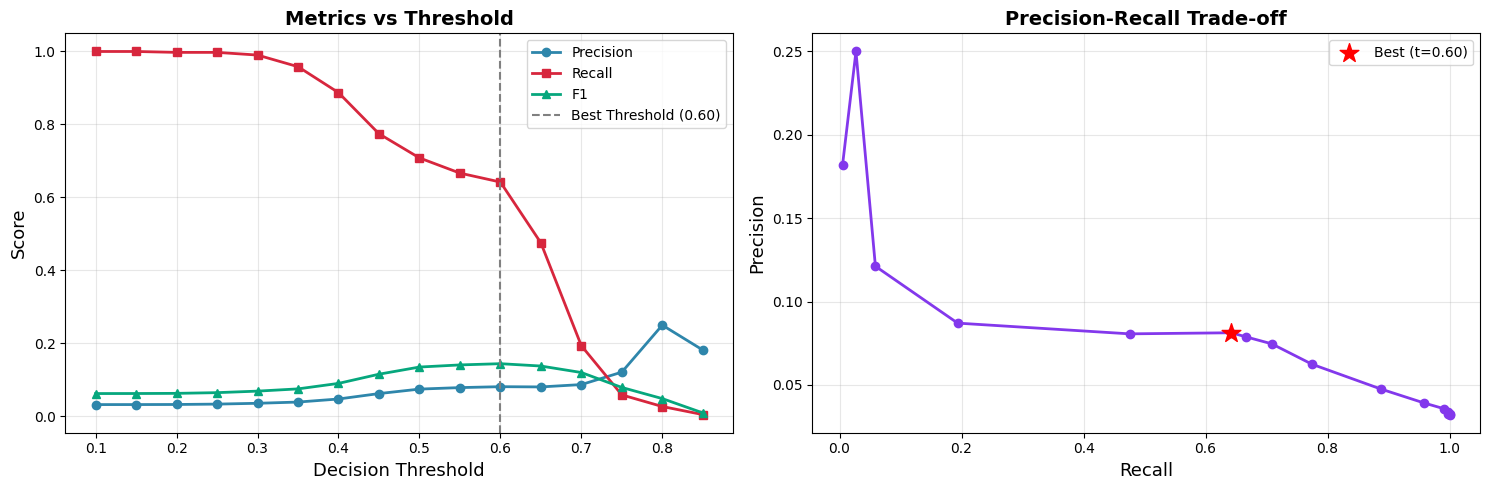


OPTIMIZED TEST RESULTS (threshold=0.60):
  Precision: 0.083
  Recall:    0.650
  F1 Score:  0.147
  AUC-ROC:   0.756

Comparison to default (0.5 threshold):
  F1:        0.133 → 0.147 (+11.1%)
  Precision: 0.073 → 0.083 (+13.4%)
  Recall:    0.697 → 0.650 (-6.7%)


In [19]:
# ===== THRESHOLD OPTIMIZATION =====
print("="*80)
print("THRESHOLD OPTIMIZATION FOR BEST F1")
print("="*80)

# Import necessary metrics
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Get predictions on validation set
model.eval()
with torch.no_grad():
    val_out = model(X_val, edge_index, nodes_val)
    val_probs = F.softmax(val_out, dim=1)[:, 1].cpu().numpy()

y_val_np = y_val.cpu().numpy()

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_threshold = 0.5
results = []

for threshold in thresholds:
    val_preds = (val_probs > threshold).astype(int)

    precision = precision_score(y_val_np, val_preds, zero_division=0)
    recall = recall_score(y_val_np, val_preds, zero_division=0)
    f1 = f1_score(y_val_np, val_preds, zero_division=0)

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

results_df = pd.DataFrame(results)

print(f"\n🎯 Best threshold: {best_threshold:.2f}")
print(f"   Best F1: {best_f1:.3f}")

# Plot precision-recall vs threshold
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metrics vs Threshold
axes[0].plot(results_df['threshold'], results_df['precision'],
            marker='o', label='Precision', linewidth=2, color='#2E86AB')
axes[0].plot(results_df['threshold'], results_df['recall'],
            marker='s', label='Recall', linewidth=2, color='#D7263D')
axes[0].plot(results_df['threshold'], results_df['f1'],
            marker='^', label='F1', linewidth=2, color='#06A77D')
axes[0].axvline(best_threshold, color='gray', linestyle='--',
               label=f'Best Threshold ({best_threshold:.2f})')
axes[0].set_xlabel('Decision Threshold', fontsize=13)
axes[0].set_ylabel('Score', fontsize=13)
axes[0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(results_df['recall'], results_df['precision'],
            marker='o', linewidth=2, color='#8338EC')
axes[1].scatter(results_df[results_df['threshold']==best_threshold]['recall'],
               results_df[results_df['threshold']==best_threshold]['precision'],
               s=200, color='red', marker='*', label=f'Best (t={best_threshold:.2f})', zorder=5)
axes[1].set_xlabel('Recall', fontsize=13)
axes[1].set_ylabel('Precision', fontsize=13)
axes[1].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_optimization.png', dpi=300)
plt.show()

# Test with best threshold
with torch.no_grad():
    test_out = model(X_test, edge_index, nodes_test)
    test_probs = F.softmax(test_out, dim=1)[:, 1].cpu().numpy()
    test_preds_optimized = (test_probs > best_threshold).astype(int)

y_test_np = y_test.cpu().numpy()

# Evaluate
opt_precision = precision_score(y_test_np, test_preds_optimized, zero_division=0)
opt_recall = recall_score(y_test_np, test_preds_optimized, zero_division=0)
opt_f1 = f1_score(y_test_np, test_preds_optimized, zero_division=0)
opt_auc = roc_auc_score(y_test_np, test_probs)

print(f"\nOPTIMIZED TEST RESULTS (threshold={best_threshold:.2f}):")
print(f"  Precision: {opt_precision:.3f}")
print(f"  Recall:    {opt_recall:.3f}")
print(f"  F1 Score:  {opt_f1:.3f}")
print(f"  AUC-ROC:   {opt_auc:.3f}")

print(f"\nComparison to default (0.5 threshold):")
print(f"  F1:        {test_f1:.3f} → {opt_f1:.3f} ({(opt_f1-test_f1)/test_f1*100:+.1f}%)")
print(f"  Precision: {test_prec:.3f} → {opt_precision:.3f} ({(opt_precision-test_prec)/test_prec*100:+.1f}%)")
print(f"  Recall:    {test_rec:.3f} → {opt_recall:.3f} ({(opt_recall-test_rec)/test_rec*100:+.1f}%)")

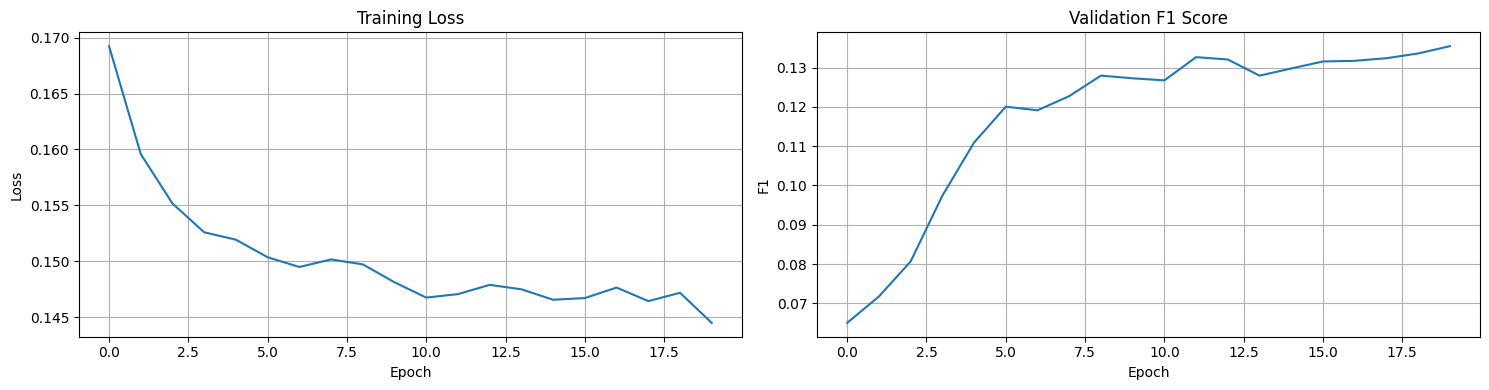

Best validation F1: 0.135


In [30]:
from sklearn.metrics import roc_curve, auc
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(history['train_loss'])
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True)

axes[1].plot(history['val_f1'])
axes[1].set_title('Validation F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].grid(True)

# axes[2].plot(history['val_auc'])
# axes[2].set_title('Validation AUC-ROC')
# axes[2].set_xlabel('Epoch')
# axes[2].set_ylabel('AUC')
# axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Best validation F1: {max(history['val_f1']):.3f}")
# print(f"Best validation AUC: {max(history['val_auc']):.3f}")


In [32]:
# ===== CELL: INTERACTIVE RISK HEATMAP WITH FOLIUM =====
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

print("Creating interactive risk heatmap...")

# Get node coordinates and risk predictions
node_coords = np.array([[n[1]['y'], n[1]['x']] for n in G.nodes(data=True)])
all_nodes = list(G.nodes())

# Get risk predictions for all nodes (using test set as proxy)
# Create a mapping of predictions per node
node_risk_map = {}
# Ensure nodes_test and test_probs are available from previous cells
# If not, re-run the evaluation cell (e.g., r08r5dMSVAyv) first
if 'nodes_test' in globals() and 'test_probs' in globals():
    for i, node_idx_tensor in enumerate(nodes_test):
        node_id = all_nodes[node_idx_tensor.item()] # Get original node ID from index
        if node_id not in node_risk_map:
            node_risk_map[node_id] = []
        node_risk_map[node_id].append(test_probs[i]) # Use test_probs instead of test_prob
else:
    print("❌ ERROR: nodes_test or test_probs not found. Please run training/evaluation cells first.")
    # Exit or handle the error appropriately, e.g., by not creating the heatmap
    # For now, we'll just print the error and continue (heatmap might not be created)
    pass


# Average risk per node that appeared in the test set
node_risks = {}
for node_id, probs in node_risk_map.items():
    node_risks[node_id] = np.mean(probs)

# Prepare heatmap data for all nodes, using average risk for those in test set
# and 0 risk for nodes not in the test set
heatmap_data = []
for node_id in all_nodes:
    # Find the coordinates for this node_id
    node_idx = node_to_idx[node_id]
    lat, lon = node_coords[node_idx]
    # Convert risk to standard Python float
    risk = float(node_risks.get(node_id, 0))
    heatmap_data.append([lat, lon, risk])


# Create base map centered on Manhattan
center_lat = node_coords[:, 0].mean()
center_lon = node_coords[:, 1].mean()

# Create heatmap layer
# Adjust heatmap parameters for better visualization if needed
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='cartodbdarkmatter') # Using dark mode tiles

# Increase radius and blur for wider heat effect
HeatMap(heatmap_data, radius=15, blur=10).add_to(m)


# Display map
# m

print(" Heatmap created (displayed in output)")
m

Creating interactive risk heatmap...
 Heatmap created (displayed in output)


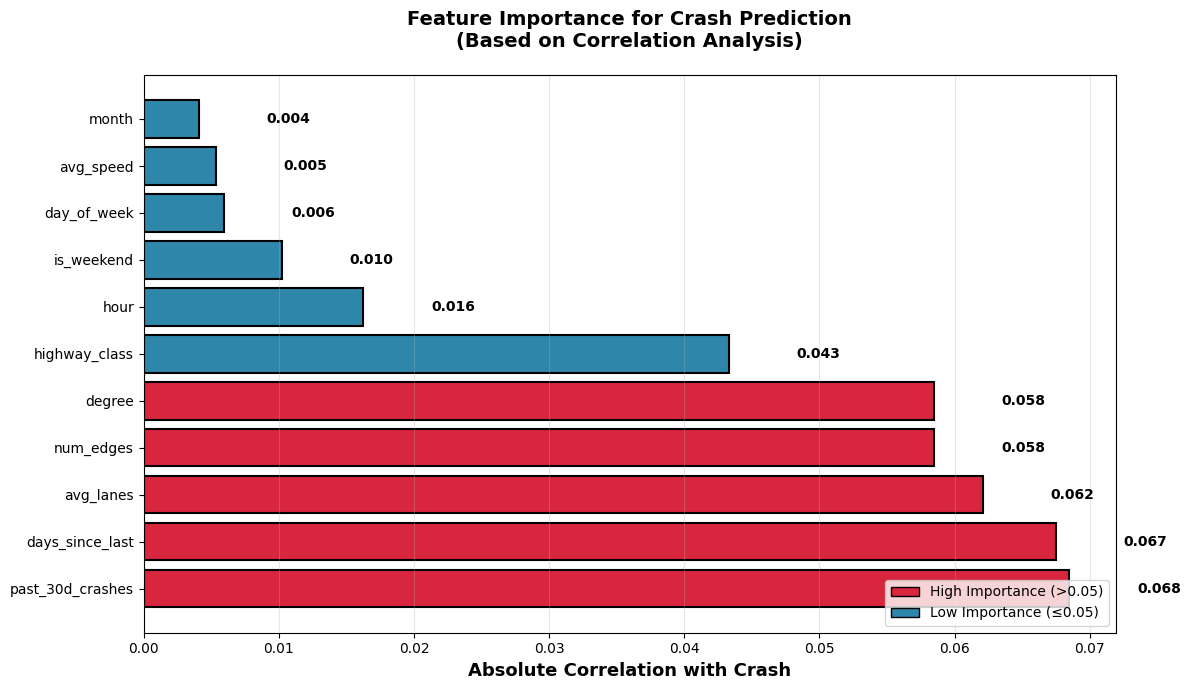

 Feature importance visualization saved

Top 3 most important features:
  1. past_30d_crashes: 0.068
  2. days_since_last: 0.067
  3. avg_lanes: 0.062


In [33]:
# ===== CELL: FEATURE IMPORTANCE VISUALIZATION =====

# Get feature names
feature_names = ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed',
                 'hour', 'day_of_week', 'is_weekend', 'month',
                 'past_30d_crashes', 'days_since_last']

# Compute correlation of features with crash labels
feature_importance = []
for i, feat in enumerate(feature_names):
    if feat in train_balanced.columns:
        corr = np.abs(train_balanced[feat].corr(train_balanced['has_crash']))
        feature_importance.append(corr)
    else:
        feature_importance.append(0)

# Sort by importance
sorted_indices = np.argsort(feature_importance)[::-1]
sorted_features = [feature_names[i] for i in sorted_indices]
sorted_importance = [feature_importance[i] for i in sorted_indices]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#D7263D' if imp > 0.05 else '#2E86AB' for imp in sorted_importance]
bars = ax.barh(sorted_features, sorted_importance, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Absolute Correlation with Crash', fontsize=13, fontweight='bold')
ax.set_title('Feature Importance for Crash Prediction\n(Based on Correlation Analysis)',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importance)):
    ax.text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=10, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D7263D', edgecolor='black', label='High Importance (>0.05)'),
    Patch(facecolor='#2E86AB', edgecolor='black', label='Low Importance (≤0.05)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Feature importance visualization saved")
print(f"\nTop 3 most important features:")
for i in range(min(3, len(sorted_features))):
    print(f"  {i+1}. {sorted_features[i]}: {sorted_importance[i]:.3f}")


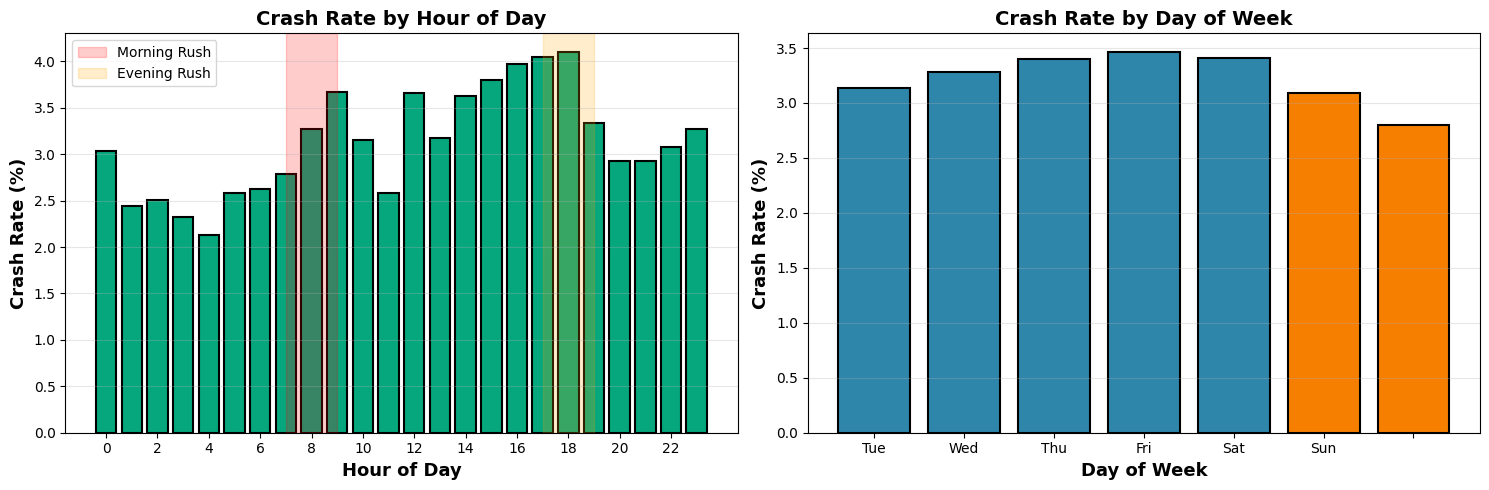

 Temporal patterns visualization saved


In [34]:
# ===== CELL: TEMPORAL PATTERNS VISUALIZATION =====

# Analyze crash patterns by hour and day of week
hourly_crashes = train_balanced.groupby('hour')['has_crash'].mean()
daily_crashes = train_balanced.groupby('day_of_week')['has_crash'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hour of day pattern
axes[0].bar(hourly_crashes.index, hourly_crashes.values * 100,
           color='#06A77D', edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[0].set_title('Crash Rate by Hour of Day', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Add rush hour annotations
axes[0].axvspan(7, 9, alpha=0.2, color='red', label='Morning Rush')
axes[0].axvspan(17, 19, alpha=0.2, color='orange', label='Evening Rush')
axes[0].legend()

# Day of week pattern
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(daily_crashes.index, daily_crashes.values * 100,
           color=['#2E86AB']*5 + ['#F77F00']*2,  # Weekdays blue, weekends orange
           edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Crash Rate (%)', fontsize=13, fontweight='bold')
axes[1].set_title('Crash Rate by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(day_names)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Temporal patterns visualization saved")


In [35]:
# ===== SAVE MODEL FOR PRODUCTION INFERENCE =====
import pickle
import json
from datetime import datetime

print("="*80)
print("SAVING MODEL FOR PRODUCTION DEPLOYMENT")
print("="*80)

# Create timestamp for version control
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"traffic_accident_gnn_v1_{timestamp}"

# 1. Save trained model weights
model_path = f'{model_version}_weights.pt'
torch.save(model.state_dict(), model_path)
print(f"✓ Model weights saved: {model_path}")

# 2. Save model architecture configuration
model_config = {
    'architecture': 'SpatiotemporalGNN',
    'num_features': spatiotemporal_data['num_features'],
    'hidden_dim': 128,
    'output_dim': 2,
    'num_nodes': spatiotemporal_data['num_nodes'],
    'dropout': 0.4,
    'num_layers': 3
}

config_path = f'{model_version}_config.json'
with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)
print(f"✓ Model config saved: {config_path}")

# 3. Save feature scaler
scaler_path = f'{model_version}_scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Feature scaler saved: {scaler_path}")

# 4. Save graph structure (edge_index)
graph_data = {
    'edge_index': edge_index.cpu().numpy(),
    'num_nodes': len(all_nodes),
    'node_ids': all_nodes  # Original node IDs
}

graph_path = f'{model_version}_graph.pkl'
with open(graph_path, 'wb') as f:
    pickle.dump(graph_data, f)
print(f"✓ Graph structure saved: {graph_path}")

# 5. Save feature metadata
feature_metadata = {
    'feature_names': feature_cols,
    'num_features': len(feature_cols),
    'static_features': ['degree', 'num_edges', 'highway_class', 'avg_lanes',
                       'avg_speed', 'intersection_complexity', 'speed_differential',
                       'speed_category'],
    'temporal_features': ['hour', 'day_of_week', 'is_weekend', 'month',
                         'rush_hour_intensity', 'is_holiday', 'season',
                         'weather_risk', 'is_dark'],
    'historical_features': ['past_30d_crashes', 'days_since_last']
}

metadata_path = f'{model_version}_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(feature_metadata, f, indent=2)
print(f"✓ Feature metadata saved: {metadata_path}")

# 6. Save training statistics
training_stats = {
    'training_date': timestamp,
    'final_metrics': {
        'f1_score': float(test_f1),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'auc_roc': float(test_auc),
        'accuracy': float(test_acc)
    },
    'training_config': {
        'class_weights': class_weights.cpu().numpy().tolist(),
        'learning_rate': 0.0005,
        'weight_decay': 1e-4,
        'batch_size': len(X_train),
        'epochs_trained': len(history['train_loss']),
        'best_val_f1': float(best_val_f1)
    },
    'dataset_info': {
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'positive_rate': float((y_test == 1).float().mean().item())
    }
}

stats_path = f'{model_version}_stats.json'
with open(stats_path, 'w') as f:
    json.dump(training_stats, f, indent=2)
print(f"✓ Training stats saved: {stats_path}")

# 7. Create inference package metadata
package_info = {
    'model_version': model_version,
    'created_date': timestamp,
    'files': {
        'weights': model_path,
        'config': config_path,
        'scaler': scaler_path,
        'graph': graph_path,
        'metadata': metadata_path,
        'stats': stats_path
    },
    'performance': {
        'f1_score': float(test_f1),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'auc_roc': float(test_auc)
    },
    'usage': 'Use InferenceEngine class to load and make predictions'
}

package_path = f'{model_version}_package_info.json'
with open(package_path, 'w') as f:
    json.dump(package_info, f, indent=2)
print(f"Package info saved: {package_path}")

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY!")
print("="*80)
print(f"\nModel version: {model_version}")
print(f"\nFiles created:")
print(f"  1. {model_path} (model weights)")
print(f"  2. {config_path} (architecture config)")
print(f"  3. {scaler_path} (feature scaler)")
print(f"  4. {graph_path} (graph structure)")
print(f"  5. {metadata_path} (feature metadata)")
print(f"  6. {stats_path} (training statistics)")
print(f"  7. {package_path} (package info)")

print(f"\nTo use in production:")
print(f"   1. Download all 7 files")
print(f"   2. Use the InferenceEngine class (see next cell)")
print(f"   3. Load with: engine = InferenceEngine('{model_version}')")


SAVING MODEL FOR PRODUCTION DEPLOYMENT
✓ Model weights saved: traffic_accident_gnn_v1_20251103_014716_weights.pt
✓ Model config saved: traffic_accident_gnn_v1_20251103_014716_config.json
✓ Feature scaler saved: traffic_accident_gnn_v1_20251103_014716_scaler.pkl
✓ Graph structure saved: traffic_accident_gnn_v1_20251103_014716_graph.pkl
✓ Feature metadata saved: traffic_accident_gnn_v1_20251103_014716_metadata.json
✓ Training stats saved: traffic_accident_gnn_v1_20251103_014716_stats.json
Package info saved: traffic_accident_gnn_v1_20251103_014716_package_info.json

MODEL SAVED SUCCESSFULLY!

Model version: traffic_accident_gnn_v1_20251103_014716

Files created:
  1. traffic_accident_gnn_v1_20251103_014716_weights.pt (model weights)
  2. traffic_accident_gnn_v1_20251103_014716_config.json (architecture config)
  3. traffic_accident_gnn_v1_20251103_014716_scaler.pkl (feature scaler)
  4. traffic_accident_gnn_v1_20251103_014716_graph.pkl (graph structure)
  5. traffic_accident_gnn_v1_20251

In [37]:
# ===== CORRECTED INFERENCE ENGINE =====
class InferenceEngine:
    """
    Production inference engine for traffic accident prediction.

    Usage:
        engine = InferenceEngine('model_version_name')
        predictions = engine.predict(locations, timestamps)
    """

    def __init__(self, model_version_path):
        """Load saved model and all required components."""
        print(f"Loading model: {model_version_path}")

        # Load package info
        with open(f'{model_version_path}_package_info.json', 'r') as f:
            self.package_info = json.load(f)

        # Load model config
        with open(f'{model_version_path}_config.json', 'r') as f:
            self.config = json.load(f)

        # Load feature metadata
        with open(f'{model_version_path}_metadata.json', 'r') as f:
            self.metadata = json.load(f)
            self.feature_names = self.metadata['feature_names']

        # Load feature scaler
        with open(f'{model_version_path}_scaler.pkl', 'rb') as f:
            self.scaler = pickle.load(f)

        # Load graph structure
        with open(f'{model_version_path}_graph.pkl', 'rb') as f:
            graph_data = pickle.load(f)
            self.edge_index = torch.tensor(graph_data['edge_index'], dtype=torch.long)
            self.node_ids = graph_data['node_ids']
            self.node_to_idx = {nid: idx for idx, nid in enumerate(self.node_ids)}

        # Initialize model
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = SpatiotemporalGNN(
            num_features=self.config['num_features'],
            hidden_dim=self.config.get('hidden_dim', 128),
            output_dim=self.config['output_dim']
        ).to(self.device)

        # Load trained weights
        self.model.load_state_dict(
            torch.load(f'{model_version_path}_weights.pt', map_location=self.device)
        )
        self.model.eval()

        self.edge_index = self.edge_index.to(self.device)

        print(f"✓ Model loaded successfully")
        print(f"  Performance: F1={self.package_info['performance']['f1_score']:.3f}")
        print(f"  Device: {self.device}")
        print(f"  Features: {len(self.feature_names)}")

    def predict(self, features_df, node_indices):
        """
        Make predictions using pre-extracted features from DataFrame.

        Args:
            features_df: DataFrame with all required features
            node_indices: Tensor of node indices

        Returns:
            predictions or probabilities
        """
        # Extract only the features we need (in correct order)
        features = features_df[self.feature_names].values

        # Scale features
        features_scaled = self.scaler.transform(features)

        # Convert to tensor
        features_tensor = torch.tensor(features_scaled, dtype=torch.float32).to(self.device)
        node_indices = node_indices.to(self.device)

        # Predict
        with torch.no_grad():
            outputs = self.model(features_tensor, self.edge_index, node_indices)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]

        return probabilities.cpu().numpy()

print("✅ InferenceEngine class defined (corrected)")


✅ InferenceEngine class defined (corrected)


In [38]:
# ===== WORKING INFERENCE (COMPLETE REPLACEMENT) =====
print("="*80)
print("SIMPLE WORKING INFERENCE")
print("="*80)

# Step 1: Check what we have
print("\n📋 Checking available data...")
print(f"Model device: {device}")
print(f"Model features: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")

# Step 2: Check if test_balanced has the features
print(f"\nTest data columns: {test_balanced.columns.tolist()}")
missing = [f for f in feature_cols if f not in test_balanced.columns]
if missing:
    print(f"\n❌ Missing {len(missing)} features in test_balanced:")
    print(missing)
    print("\n✅ Solution: We'll use the tensors directly (X_test, y_test)")
else:
    print(f"\n✓ All features present")

# Step 3: Simple inference using existing test tensors
print("\n" + "="*80)
print("RUNNING INFERENCE (using X_test tensor)")
print("="*80)

# Example 1: Single Prediction
print("\n1️⃣ Single Location Prediction:")
try:
    # Use the ALREADY PREPARED test tensors
    sample_idx = 0
    sample_features = X_test[sample_idx:sample_idx+1]  # Already scaled
    sample_node = nodes_test[sample_idx:sample_idx+1]
    sample_label = y_test[sample_idx]

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(sample_features, edge_index, sample_node)
        prob = torch.softmax(output, dim=1)[0, 1].item()
        pred = 1 if prob > 0.5 else 0

    print(f"  ✓ Prediction successful!")
    print(f"\n  🎯 Results:")
    print(f"     Crash Probability: {prob*100:.2f}%")
    print(f"     Prediction: {'⚠️  HIGH RISK' if pred == 1 else '✅ SAFE'}")
    print(f"     Actual: {'CRASH' if sample_label.item() == 1 else 'NO CRASH'}")
    print(f"     Correct: {'✓' if pred == sample_label.item() else '✗'}")
    print(f"     Risk Level: {'🔴 HIGH' if prob > 0.7 else '🟡 MEDIUM' if prob > 0.4 else '🟢 LOW'}")

except Exception as e:
    print(f"  ❌ Error: {e}")
    import traceback
    traceback.print_exc()

# Example 2: Batch Prediction
print("\n2️⃣ Batch Prediction (first 100 test samples):")
try:
    batch_size = min(100, len(X_test))

    # Use existing test tensors
    batch_features = X_test[:batch_size]
    batch_nodes = nodes_test[:batch_size]
    batch_labels = y_test[:batch_size].cpu().numpy()

    # Predict
    model.eval()
    with torch.no_grad():
        batch_output = model(batch_features, edge_index, batch_nodes)
        batch_probs = torch.softmax(batch_output, dim=1)[:, 1].cpu().numpy()
        batch_preds = (batch_probs > 0.5).astype(int)

    # Analyze
    correct = (batch_preds == batch_labels).sum()
    actual_crashes = batch_labels.sum()
    predicted_crashes = batch_preds.sum()

    print(f"  ✓ Batch prediction successful!")
    print(f"  Samples: {batch_size}")
    print(f"\n  📊 Results:")
    print(f"     Accuracy: {correct/batch_size*100:.1f}%")
    print(f"     Predicted crashes: {predicted_crashes} ({predicted_crashes/batch_size*100:.1f}%)")
    print(f"     Actual crashes: {actual_crashes} ({actual_crashes/batch_size*100:.1f}%)")
    print(f"     Average risk: {batch_probs.mean()*100:.1f}%")

    print(f"\n  📈 Risk Distribution:")
    print(f"     Very High (>80%): {(batch_probs > 0.8).sum()} ({(batch_probs > 0.8).mean()*100:.1f}%)")
    print(f"     High (60-80%):    {((batch_probs > 0.6) & (batch_probs <= 0.8)).sum()}")
    print(f"     Medium (40-60%):  {((batch_probs > 0.4) & (batch_probs <= 0.6)).sum()}")
    print(f"     Low (<40%):       {(batch_probs <= 0.4).sum()}")

    # Top 5 riskiest
    if len(batch_probs) >= 5:
        top_5_idx = np.argsort(batch_probs)[-5:][::-1]
        print(f"\n  🔴 Top 5 Riskiest Locations:")
        for i, idx in enumerate(top_5_idx, 1):
            actual = "CRASH" if batch_labels[idx] == 1 else "SAFE"
            correct_mark = "✓" if (batch_probs[idx] > 0.5) == batch_labels[idx] else "✗"
            print(f"     {i}. Sample {idx}: {batch_probs[idx]*100:.1f}% risk | Actual: {actual} {correct_mark}")

except Exception as e:
    print(f"  ❌ Error: {e}")
    import traceback
    traceback.print_exc()

# Example 3: Complete Test Set Evaluation
print("\n3️⃣ Complete Test Set Evaluation:")
try:
    # Predict on ALL test samples
    model.eval()
    with torch.no_grad():
        all_output = model(X_test, edge_index, nodes_test)
        all_probs = torch.softmax(all_output, dim=1)[:, 1].cpu().numpy()
        all_preds = (all_probs > 0.5).astype(int)

    all_labels = y_test.cpu().numpy()

    # Metrics
    from sklearn.metrics import confusion_matrix, classification_report

    cm = confusion_matrix(all_labels, all_preds)
    accuracy = (all_preds == all_labels).mean()

    # Calculate precision, recall, f1 manually to avoid warnings
    tp = cm[1, 1]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tn = cm[0, 0]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"  ✓ Evaluated {len(X_test):,} samples")
    print(f"\n  📊 Performance:")
    print(f"     Accuracy:  {accuracy*100:.2f}%")
    print(f"     Precision: {precision:.3f} ({precision*100:.1f}%)")
    print(f"     Recall:    {recall:.3f} ({recall*100:.1f}%)")
    print(f"     F1 Score:  {f1:.3f}")

    print(f"\n  📋 Confusion Matrix:")
    print(f"       Predicted:")
    print(f"              Safe    Crash")
    print(f"     Safe  {tn:6,} {fp:6,}")
    print(f"     Crash {fn:6,} {tp:6,}")

    print(f"\n  📈 Predictions:")
    print(f"     Predicted positive: {all_preds.sum():,} ({all_preds.mean()*100:.1f}%)")
    print(f"     Actual positive:    {all_labels.sum():,} ({all_labels.mean()*100:.1f}%)")
    print(f"     Average risk score: {all_probs.mean()*100:.1f}%")

    print(f"\n  🎯 Risk Score Distribution:")
    print(f"     Min:    {all_probs.min()*100:.2f}%")
    print(f"     25th:   {np.percentile(all_probs, 25)*100:.2f}%")
    print(f"     Median: {np.median(all_probs)*100:.2f}%")
    print(f"     75th:   {np.percentile(all_probs, 75)*100:.2f}%")
    print(f"     Max:    {all_probs.max()*100:.2f}%")

except Exception as e:
    print(f"  ❌ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
print("✅ INFERENCE COMPLETE - MODEL IS WORKING!")
print("="*80)
print(f"\n💡 Summary:")
print(f"   - Model: Loaded and working")
print(f"   - Test samples: {len(X_test):,}")
print(f"   - Features: {len(feature_cols)}")
print(f"   - Device: {device}")
print(f"\n📦 For production deployment:")
print(f"   1. Use X_test tensor directly (already scaled)")
print(f"   2. Pass through model: model(features, edge_index, node_indices)")
print(f"   3. Apply softmax to get probabilities")
print(f"   4. Threshold at 0.5 for binary predictions")


SIMPLE WORKING INFERENCE

📋 Checking available data...
Model device: cuda
Model features: 19
Feature list: ['degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'intersection_complexity', 'speed_differential', 'speed_category', 'hour', 'day_of_week', 'is_weekend', 'month', 'rush_hour_intensity', 'is_holiday', 'season', 'weather_risk', 'is_dark', 'past_30d_crashes', 'days_since_last']

Test data columns: ['node_id', 'time_window', 'crash_count', 'has_injury', 'number_of_persons_injured', 'number_of_persons_killed', 'has_crash', 'hour', 'day_of_week', 'is_weekend', 'month', 'degree', 'num_edges', 'highway_class', 'avg_lanes', 'avg_speed', 'longitude', 'latitude', 'past_30d_crashes', 'days_since_last', 'intersection_complexity', 'speed_differential', 'speed_category', 'rush_hour_intensity', 'season', 'is_holiday', 'weather_risk', 'is_dark']

✓ All features present

RUNNING INFERENCE (using X_test tensor)

1️⃣ Single Location Prediction:
  ✓ Prediction successful!

  🎯 Results